In [61]:
# from ultralytics import RTDETR

# model = RTDETR("rtdetr-l.pt")
# model.info()

# results = model.train(data='./Scananagrams.yolov8', epochs = 50, imgsz=640)

## Read in Image, Identify Tiles


image 1/1 c:\IzzysWorkshop\PeelBack\unAnnotatedImages\Reddit2.jpeg: 640x640 31 Tiles, 419.5ms
Speed: 3.5ms preprocess, 419.5ms inference, 0.4ms postprocess per image at shape (1, 3, 640, 640)
average Tile Length: 191.6290322580645
Total tiles scanned: 31


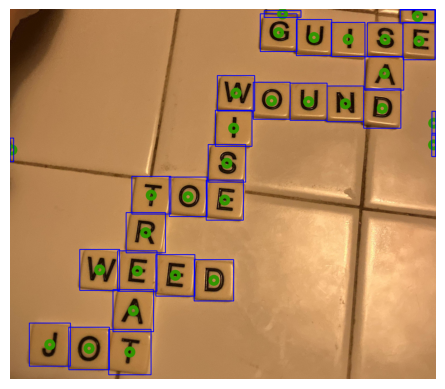

In [64]:
import cv2
import matplotlib.pyplot as plt
from ultralytics import RTDETR
import numpy as np
from Scananagrams.src import helper


imagePath = 'unAnnotatedImages/Reddit2.jpeg'

image = cv2.imread(imagePath, cv2.IMREAD_COLOR_RGB)

drawOn = image.copy()

myModel = RTDETR('runs/detect/train/weights/best.pt')
result = myModel.predict(imagePath)

boxes = result[0].boxes.xyxy.cpu().numpy()
boxes = boxes.astype(np.int64)
centers = []

for x1,y1,x2,y2 in boxes:
    # x1,y1,x2,y2 = map(int,box)
    xAvg = (x1+x2)//2
    yAvg = (y1+y2)//2
    centers.append([xAvg,yAvg])

    cv2.circle(drawOn, (xAvg,yAvg),20,(50,150,0),20)
    cv2.rectangle(drawOn, (x1,y1),(x2,y2), (0,0,250),3)

centers = np.asarray(centers)

avgTileLen = helper.findNewAvgTileLen(boxes)

print(f'average Tile Length: {avgTileLen}')
print(f'Total tiles scanned: {len(boxes)}')
plt.imshow(drawOn)
plt.axis('off')
plt.show()

## Filter for duplicates and false positives

### Filter By Aspect Ratio 

In [65]:
heights = boxes[:,3] - boxes[:,1]
widths = boxes[:,2] - boxes[:,0]
aspectRatios = widths/heights

ratioMOE = .35
minRatio, maxRatio = helper.percentCI(1,ratioMOE)

conditions = (minRatio<aspectRatios) & (aspectRatios<maxRatio) 
boxes = boxes[conditions]
centers=centers[conditions]
len(boxes)

25

### Filter by Length and Width

In [69]:
#avgTileLen needs to be recalculated now that ratio has been filtered
avgTileLen = helper.findNewAvgTileLen(boxes)

heights = boxes[:,3] - boxes[:,1]
widths = boxes[:,2] - boxes[:,0]

lenMOE = .25
minLen,maxLen = helper.percentCI(avgTileLen,lenMOE)

conditions = (widths<maxLen) & (widths>minLen) & (heights>minLen) & (heights<maxLen) 
boxes = boxes[conditions]
centers=centers[conditions]
len(boxes)


25

### Filter For Duplicates

In [67]:
from sklearn.neighbors import NearestNeighbors
neigh = NearestNeighbors(n_neighbors=6, algorithm='ball_tree').fit(centers)
indices = neigh.kneighbors(centers, return_distance=False)

In [68]:
avgTileLen = helper.findNewAvgTileLen(boxes)

duplicates=[]
for neighbors in indices:
    mainTile = centers[neighbors[0]]
    for neighbor in neighbors[1:]:
        diffX = mainTile[0] - centers[neighbor][0]
        diffY = mainTile[1] - centers[neighbor][1]
        if ( abs(diffX) < avgTileLen/2 and abs(diffY) < avgTileLen/2 ):
            print(f'Overlap found - ({mainTile[0]},{mainTile[1]}) and ({centers[neighbor][0]},{centers[neighbor][1]}) ')
            if(neighbors[0] not in duplicates):
                duplicates.append(neighbor)

boxes=np.delete(boxes,duplicates,axis=0)
centers = np.delete(centers,duplicates, axis=0)

len(centers)

25

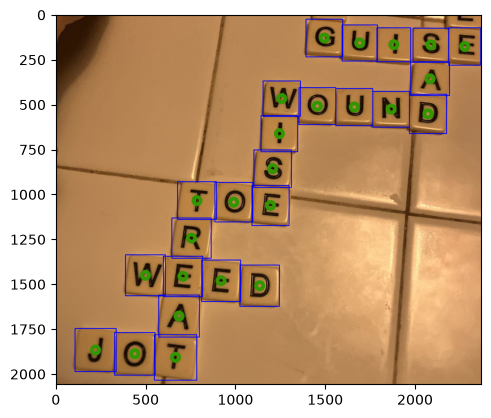

25

In [70]:
drawOn2 = image.copy()

for x1,y1,x2,y2 in boxes:
    xAvg = (x1+x2)//2
    yAvg = (y1+y2)//2
    avgTileLen += x2-x1
    avgTileLen += y2-y1

    cv2.circle(drawOn2, (xAvg,yAvg),20,(50,150,0),20)
    cv2.rectangle(drawOn2, (x1,y1),(x2,y2), (0,0,250),3)

plt.imshow(drawOn2)
plt.show()
len(boxes)

## Crop and export

In [51]:
from cv2.typing import MatLike

def getCropped(image:MatLike, box) -> MatLike:
    x1,y1,x2,y2 = map(int, box)
    croppedImage = image[y1:y2,x1:x2]
    return croppedImage

def exportImage(image:MatLike, fileName, basePath='cnnTraining'):
    fullPath = f'./{basePath}/{fileName}.jpg'
    cv2.imwrite(fullPath,image)

In [52]:
# import os

# batch = 'Batch2'
# imageDir = 'cnnTraining/_Full_Images'
# fullPath = os.path.join(imageDir,batch)
# print(fullPath)
# count = 0

# images = [imageFile for _,_, imageFile in os.walk(fullPath)][0]
# print(images)

# for imageFilePath in images:
#     imageFullPath = os.path.join(fullPath,imageFilePath)
#     image = cv2.imread(imageFullPath)
#     result = myModel.predict(image)
#     boxes = result[0].boxes.xyxy.cpu().numpy()
#     for crop in boxes:
#         croppedImage = getCropped(image,crop)
#         croppedOutPath = os.path.join('cnnTraining',f'{count}.jpg')
#         exportImage(croppedImage,str(count))
#         count+=1


## Determine Letter of Each Box

In [71]:
import torch
import string
from Scananagrams.src.cnn.OCRModel import SingleCharOCR, ImageDataset
from torch.utils.data import DataLoader
from torchvision.transforms import transforms


cv_letters = [ image[y1:y2,x1:x2] for x1,y1,x2,y2 in boxes]
transform = transforms.Compose([
    transforms.Resize((20,20)),
    transforms.ToTensor()
])
dataset = ImageDataset(cv_letters,transform)
dataloader = DataLoader(dataset, batch_size=1, shuffle=False)


model = SingleCharOCR()
model.load_state_dict(torch.load('cnnTraining/weights/firstAttempt.pt', weights_only=True))
model.eval()

outputs = []

with torch.inference_mode():
    for batch in  dataloader:
        outputs.append(model(batch)[0])

outputs = torch.stack(outputs)
outs=torch.argmax(outputs,1)
letters = np.asarray(list(string.ascii_uppercase))
tileLetters = letters[outs]
tileLetters

array(['M', 'B', 'D', 'Q', 'I', 'A', 'S', 'Q', 'W', 'Q', 'U', 'Q', 'N', 'B', 'T', 'S', 'Q', 'R', 'W', 'A', 'T', 'B', 'S', 'M', 'I'], dtype='<U1')

## Give each box a letter, create `TileInfo` Objects

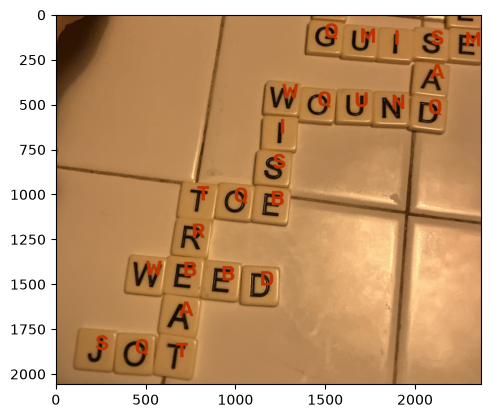

In [ ]:
from Scananagrams.src.TileInfo import TileInfo

tiles = [TileInfo(center,letter) for center,letter in zip(centers,tileLetters)]
drawOnFinal = image.copy()

for tile in tiles:
    # print(tile.letter)
    cv2.putText(drawOnFinal, tile.letter, tile.center, cv2.FONT_HERSHEY_SIMPLEX, 4.0, (190,50,0),2,bottomLeftOrigin=False)
plt.imshow(drawOnFinal)
plt.show()

## Visualize board with BFS using only letters

In [ ]:
from Scananagrams.src import GetTileNeighbors


## Letters --> Words

## Visualize board using words and intersect indices

## Neighbors 1